In [ ]:
# 기본 데이터 처리
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 날짜/시간 처리
from datetime import datetime, timedelta
from pathlib import Path

# 통계/분포 확인
from scipy import stats
# 한글 그래프 폰트 설정 - Windows/Jupyter
import matplotlib.font_manager as fm

font_path = r"C:\Windows\Fonts\malgun.ttf"
if Path(font_path).exists():
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])



In [ ]:
from pathlib import Path
import pandas as pd

SEARCH_ROOTS = [Path.cwd(), *Path.cwd().parents]

PROCESSED_DIR = next(
    (
        root / "data" / "processed"
        for root in SEARCH_ROOTS
        if (root / "data" / "processed" / "olist_order_item_level.csv").exists()
    ),
    None,
)

if PROCESSED_DIR is None:
    raise FileNotFoundError("data/processed/olist_order_item_level.csv 파일을 찾을 수 없습니다.")

df = pd.read_csv(PROCESSED_DIR / "olist_order_item_level.csv", low_memory=False)

print(PROCESSED_DIR)
print(df.shape)
df.head()

order_item_df = pd.read_csv(PROCESSED_DIR / "olist_order_item_level.csv", low_memory=False)
delivered_df = pd.read_csv(PROCESSED_DIR / "olist_delivered_item_level.csv", low_memory=False)

print(order_item_df.shape)
print(delivered_df.shape)

c:\team-oldest-olist-analysis\data\processed
(112650, 67)
(112650, 67)
(108581, 67)


In [ ]:
# EDA는 주문-상품 중복을 피하기 위해 주문 단위 데이터로 시작합니다.
datetime_cols = [
    "shipping_limit_date",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "review_creation_min",
    "review_answer_max",
]
for data in [order_item_df, delivered_df]:
    for col in datetime_cols:
        if col in data.columns:
            data[col] = pd.to_datetime(data[col], errors="coerce")
    for col in ["is_late", "is_delivered", "seller_customer_same_state"]:
        if col in data.columns:
            data[col] = data[col].map({True: True, False: False, "True": True, "False": False})
    numeric_cols = [
        "review_score_mean",
        "review_count",
        "delivery_days_clean",
        "delivery_days_all",
        "payment_value_total",
        "freight_value",
        "price",
    ]
    for col in numeric_cols:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")
order_level = (
    order_item_df
    .sort_values(["order_id", "order_item_id"])
    .drop_duplicates("order_id")
    .copy()
)
order_level["has_review"] = order_level["review_score_mean"].notna()
order_level["is_5star"] = order_level["review_score_mean"].eq(5)
order_level["is_4_or_less"] = order_level["review_score_mean"].le(4)
order_level["approval_lead_hours"] = (
    order_level["order_approved_at"] - order_level["order_purchase_timestamp"]
).dt.total_seconds() / 3600
order_level["carrier_lead_hours"] = (
    order_level["order_delivered_carrier_date"] - order_level["order_approved_at"]
).dt.total_seconds() / 3600
order_level["last_mile_days"] = (
    order_level["order_delivered_customer_date"] - order_level["order_delivered_carrier_date"]
).dt.total_seconds() / 86400
order_level["estimated_delivery_days"] = (
    order_level["order_estimated_delivery_date"] - order_level["order_purchase_timestamp"]
).dt.total_seconds() / 86400
order_level["late_days"] = (
    order_level["order_delivered_customer_date"] - order_level["order_estimated_delivery_date"]
).dt.total_seconds() / 86400
order_level["review_after_delivery_days"] = (
    order_level["review_creation_min"] - order_level["order_delivered_customer_date"]
).dt.total_seconds() / 86400
# 리뷰가 있는 주문만 별도 분석 대상으로 사용합니다.
reviewed = order_level.loc[order_level["has_review"]].copy()
print("주문-상품 데이터:", order_item_df.shape)
print("주문 단위 데이터:", order_level.shape)
display(order_level[["order_id", "customer_unique_id", "order_status", "review_score_mean", "delivery_days_clean", "late_days"]].head())


주문-상품 데이터: (112650, 67)
주문 단위 데이터: (98666, 76)


,order_id,customer_unique_id,order_status,review_score_mean,delivery_days_clean,late_days
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,delivered,5.0,7.0,-8.011250
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,delivered,4.0,16.0,-2.330278
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,delivered,5.0,7.0,-13.444954
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,delivered,4.0,6.0,-5.435660
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,delivered,5.0,25.0,-15.303808


## 1. 지연일에 따른 평점 하락 EDA

`late_days`는 실제 고객 수령일에서 배송 예정일을 뺀 값입니다. 0보다 크면 예정일보다 늦은 배송이고, 0 이하이면 예정일 이내 배송입니다. 고객 기대치가 이미 배송 예정일에 반영되어 있으므로, 골든타임과 평점 하락은 배송일수 자체보다 지연일 기준으로 보는 것이 더 적절합니다.


,late_days_bin,orders,avg_review,median_review,five_star_rate,low_review_rate,avg_delivery_days
0,7일+ 빠름,70934,4.316818,5.0,0.635802,0.363620,9.798382
1,3~6일 빠름,12529,4.226195,5.0,0.583287,0.415995,12.277800
2,예정일 이내,4705,4.133369,5.0,0.550266,0.449309,15.463284
3,1일 지연,1280,4.035547,5.0,0.504687,0.493750,18.777341
4,2~3일 지연,1356,3.513274,4.0,0.362094,0.637906,22.397921
5,4~7일 지연,1773,2.317259,1.0,0.181049,0.818951,26.148924
6,8~14일 지연,1749,1.746141,1.0,0.078902,0.921098,32.877364
7,15일+ 지연,1504,1.710771,1.0,0.069814,0.930186,52.273516


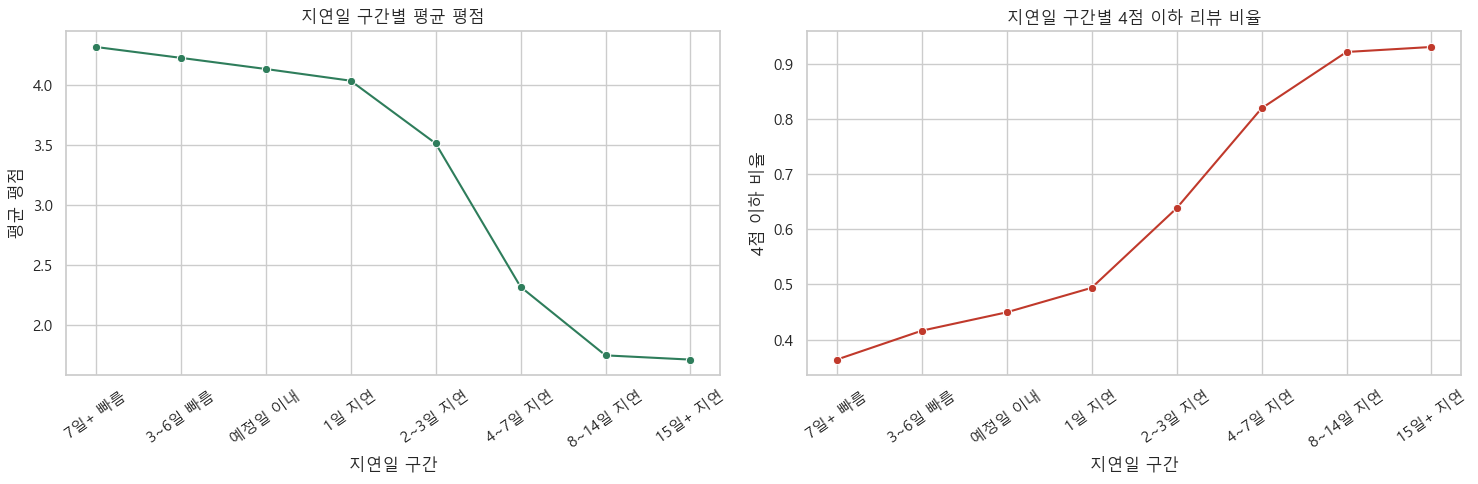

In [ ]:
late_bins = [-np.inf, -7, -3, 0, 1, 3, 7, 14, np.inf]
late_labels = ["7일+ 빠름", "3~6일 빠름", "예정일 이내", "1일 지연", "2~3일 지연", "4~7일 지연", "8~14일 지연", "15일+ 지연"]

reviewed["late_days_bin"] = pd.cut(
    reviewed["late_days"], bins=late_bins, labels=late_labels
)

late_review = (
    reviewed.dropna(subset=["late_days_bin", "review_score_mean"])
    .groupby("late_days_bin", observed=True)
    .agg(
        orders=("order_id", "nunique"),
        avg_review=("review_score_mean", "mean"),
        median_review=("review_score_mean", "median"),
        five_star_rate=("is_5star", "mean"),
        low_review_rate=("is_4_or_less", "mean"),
        avg_delivery_days=("delivery_days_clean", "mean"),
    )
    .reset_index()
)

display(late_review)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=late_review, x="late_days_bin", y="avg_review", marker="o", ax=axes[0], color="#2E7D5B")
axes[0].set_title("지연일 구간별 평균 평점")
axes[0].set_xlabel("지연일 구간")
axes[0].set_ylabel("평균 평점")
axes[0].tick_params(axis="x", rotation=35)

sns.lineplot(data=late_review, x="late_days_bin", y="low_review_rate", marker="o", ax=axes[1], color="#C0392B")
axes[1].set_title("지연일 구간별 4점 이하 리뷰 비율")
axes[1].set_xlabel("지연일 구간")
axes[1].set_ylabel("4점 이하 비율")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()


### 분석 결과 해석

- 배송 예정일보다 **7일 이상 빠르게 도착한 주문**은 평균 평점이 약 **4.32점**, 4점 이하 비율이 **36.4%**입니다.
- **예정일 이내** 도착 구간은 평균 평점이 약 **4.13점**, 4점 이하 비율이 **44.9%**로 이미 조금 낮아집니다.
- **1일 지연**에서는 평균 평점이 약 **4.04점**, 4점 이하 비율이 **49.4%**입니다.
- **2~3일 지연**부터 평균 평점이 약 **3.51점**으로 크게 떨어지고, 4점 이하 비율도 **63.8%**까지 올라갑니다.
- **4~7일 지연**은 평균 평점이 약 **2.32점**, 4점 이하 비율이 **81.9%**입니다.

따라서 고객을 붙잡을 골든타임은 늦어도 **예정일 초과 직후~2일 지연 전**으로 보는 것이 좋아 보입니다. 특히 2~3일 지연 구간부터 만족도가 급격히 무너집니다.


## 2. 지연일 기준 리뷰 하락과 단계별 소요일 EDA

첨부한 그래프는 단계별 소요일을 기준으로 평균 리뷰를 본 것입니다. 여기서는 고객 기대치가 반영된 `late_days`를 x축으로 두고, 먼저 지연일이 커질수록 평균 리뷰가 어떻게 하락하는지 확인합니다. 그 다음 같은 지연일 구간에서 `전체 리드타임`, `판매자 처리시간`, `택배사 배송시간`의 평균 소요일이 어떻게 달라지는지 분리해서 봅니다. x축은 `-10일~15일` 범위로 제한하고, 각 지연일별 주문 수가 30건 이상인 구간만 표시합니다.


,late_day_int,orders,avg_review,review_std,review_se,review_ci95
0,-10,4616,4.308348,1.126720,0.016584,0.032504
1,-9,4595,4.327530,1.103441,0.016278,0.031905
2,-8,4577,4.285340,1.150103,0.017000,0.033320
3,-7,4834,4.263860,1.165553,0.016764,0.032858
4,-6,4792,4.250104,1.149174,0.016601,0.032537
5,-5,3459,4.245302,1.132185,0.019251,0.037731
6,-4,2067,4.198113,1.207055,0.026550,0.052037
7,-3,1891,4.128503,1.221451,0.028089,0.055054
8,-2,1686,4.125148,1.224162,0.029813,0.058434
9,-1,1510,4.147682,1.221377,0.031431,0.061605


,late_day_int,orders,avg_stage_days,stage
0,-10,4534,9.847375,전체 리드타임
1,-9,4548,10.237247,전체 리드타임
2,-8,4539,10.613792,전체 리드타임
3,-7,4796,11.150125,전체 리드타임
4,-6,4751,11.536098,전체 리드타임
5,-5,3426,12.105663,전체 리드타임
6,-4,2047,13.195896,전체 리드타임
7,-3,1879,13.960085,전체 리드타임
8,-2,1672,14.774522,전체 리드타임
9,-1,1503,15.171657,전체 리드타임


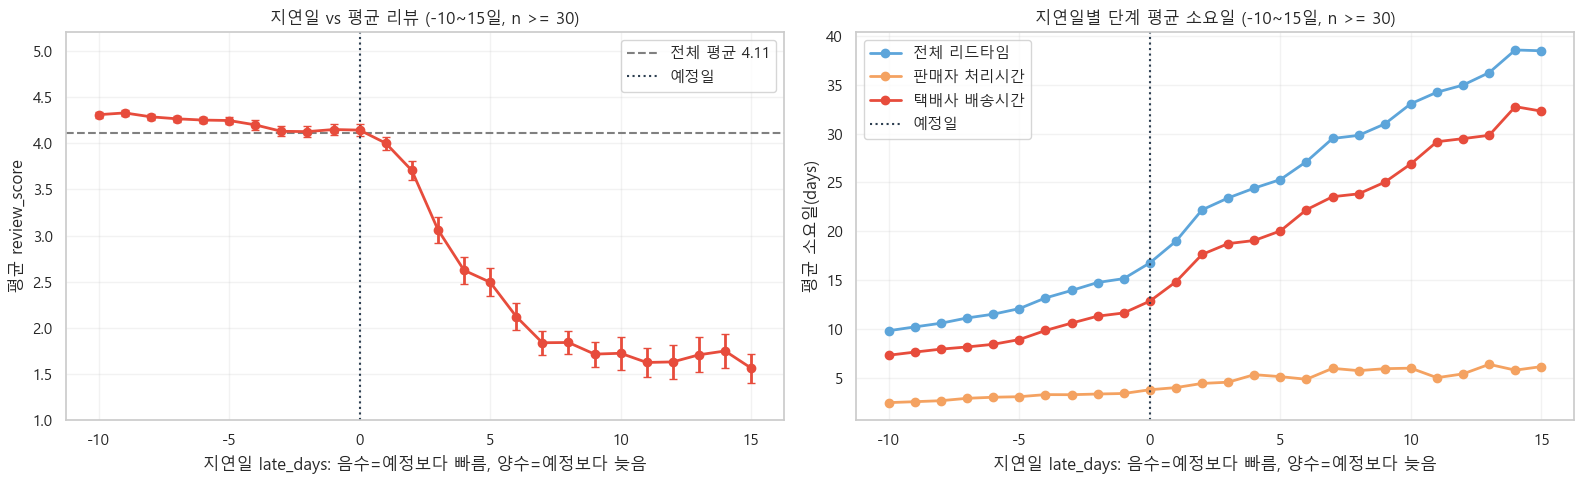

In [ ]:
# 지연일 기준으로 평균 리뷰와 단계별 평균 소요일을 분리해서 봅니다.
# 같은 지연일의 review_score는 단계와 무관하게 하나의 값이므로, 리뷰선은 1개만 그립니다.
stage_delay_base = reviewed.dropna(subset=["late_days", "review_score_mean"]).copy()
stage_delay_base["late_day_int"] = stage_delay_base["late_days"].round().astype("int")
stage_delay_base = stage_delay_base.loc[stage_delay_base["late_day_int"].between(-10, 15)].copy()

late_day_review = (
    stage_delay_base.groupby("late_day_int")
    .agg(
        orders=("order_id", "nunique"),
        avg_review=("review_score_mean", "mean"),
        review_std=("review_score_mean", "std"),
    )
    .reset_index()
)
late_day_review = late_day_review.query("orders >= 30").copy()
late_day_review["review_se"] = late_day_review["review_std"] / np.sqrt(late_day_review["orders"])
late_day_review["review_ci95"] = 1.96 * late_day_review["review_se"]

stage_specs = [
    ("전체 리드타임", "delivery_days_clean"),
    ("판매자 처리시간", "carrier_lead_hours"),
    ("택배사 배송시간", "last_mile_days"),
]

stage_delay_rows = []
for stage_name, metric_col in stage_specs:
    tmp = stage_delay_base.dropna(subset=[metric_col]).copy()
    tmp["stage_days"] = tmp[metric_col] / 24 if metric_col.endswith("_hours") else tmp[metric_col]

    grouped = (
        tmp.groupby("late_day_int")
        .agg(
            orders=("order_id", "nunique"),
            avg_stage_days=("stage_days", "mean"),
        )
        .reset_index()
    )
    grouped["stage"] = stage_name
    stage_delay_rows.append(grouped)

stage_delay_days = pd.concat(stage_delay_rows, ignore_index=True)
stage_delay_days = stage_delay_days.query("orders >= 30").copy()

display(late_day_review.head(20))
display(stage_delay_days.head(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

overall_review_mean = reviewed["review_score_mean"].mean()
axes[0].errorbar(
    late_day_review["late_day_int"],
    late_day_review["avg_review"],
    yerr=late_day_review["review_ci95"],
    marker="o",
    linewidth=2,
    capsize=3,
    color="#E74C3C",
)
axes[0].axhline(overall_review_mean, color="gray", linestyle="--", label=f"전체 평균 {overall_review_mean:.2f}")
axes[0].axvline(0, color="#2C3E50", linestyle=":", label="예정일")
axes[0].set_title("지연일 vs 평균 리뷰 (-10~15일, n >= 30)")
axes[0].set_xlabel("지연일 late_days: 음수=예정보다 빠름, 양수=예정보다 늦음")
axes[0].set_ylabel("평균 review_score")
axes[0].set_ylim(1, 5.2)
axes[0].legend()
axes[0].grid(alpha=0.25)

for stage_name, color in zip(["전체 리드타임", "판매자 처리시간", "택배사 배송시간"], ["#5DA5DA", "#F4A261", "#E74C3C"]):
    plot_data = stage_delay_days.loc[stage_delay_days["stage"].eq(stage_name)].sort_values("late_day_int")
    axes[1].plot(
        plot_data["late_day_int"],
        plot_data["avg_stage_days"],
        marker="o",
        linewidth=2,
        label=stage_name,
        color=color,
    )

axes[1].axvline(0, color="#2C3E50", linestyle=":", label="예정일")
axes[1].set_title("지연일별 단계 평균 소요일 (-10~15일, n >= 30)")
axes[1].set_xlabel("지연일 late_days: 음수=예정보다 빠름, 양수=예정보다 늦음")
axes[1].set_ylabel("평균 소요일(days)")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


### 분석 결과 해석

- 이전 그래프에서 `전체 리드타임`과 `판매자 처리시간`이 안 보였던 이유는 세 단계 모두 y축에 같은 `avg_review`를 그렸기 때문입니다. 즉, 같은 지연일의 평균 평점은 단계별로 다른 값이 아니라 하나의 값이라서 선이 겹쳤고, 마지막에 그린 `택배사 배송시간` 선이 위를 덮었습니다.
- 이제 왼쪽 그래프는 지연일별 평균 평점 하락만 보여줍니다. 예정일 전후까지는 4점대가 유지되지만, 지연이 2~3일 이상 누적되면 평점이 빠르게 내려가는 구간을 확인할 수 있습니다.
- 오른쪽 그래프는 같은 지연일 구간에서 `전체 리드타임`, `판매자 처리시간`, `택배사 배송시간`이 각각 얼마나 길었는지 보여줍니다. 이 그래프를 통해 리뷰 하락이 단순 배송 전체 기간 때문인지, 판매자 처리 지연인지, 운송사 이후 구간인지 분리해서 해석할 수 있습니다.
- 의사결정 관점에서는 왼쪽 그래프로 고객 불만이 급격히 커지는 골든타임을 잡고, 오른쪽 그래프로 그 시점에 어느 단계가 병목인지 확인하는 방식이 더 적절합니다.


## 3. 판매자 처리시간 vs 택배사 배송시간의 평점 영향 비교

여기서는 `carrier_lead_hours`를 판매자 처리시간(`order_approved_at` → `order_delivered_carrier_date`), `last_mile_days`를 택배사 배송시간(`order_delivered_carrier_date` → `order_delivered_customer_date`)으로 보고 비교합니다.

단순히 둘을 따로 보는 것만으로는 착시가 생길 수 있으므로, 1차로 구간별 평균 평점과 4점 이하 비율을 보고, 2차로 같은 회귀 모델 안에 두 변수를 함께 넣어 **1일 증가당 평점 변화량**과 **표준화 영향력**을 비교합니다.


,seller_process_bin,orders,avg_review,median_review,low_review_rate
0,~0.5일,9829,4.304405,5.0,0.359650
1,0.5~1일,17792,4.274327,5.0,0.373820
2,1~2일,22686,4.227820,5.0,0.382571
3,2~3일,14051,4.175148,5.0,0.404811
4,3~5일,16267,4.112559,5.0,0.425155
5,5일+,13824,3.797996,4.0,0.514251


,carrier_delivery_bin,orders,avg_review,median_review,low_review_rate
0,~3일,15714,4.370105,5.0,0.333779
1,3~5일,13112,4.329584,5.0,0.347621
2,5~7일,16500,4.326970,5.0,0.354909
3,7~10일,18127,4.273018,5.0,0.381475
4,10~15일,16240,4.189717,5.0,0.421552
5,15일+,14756,3.388610,4.0,0.620629


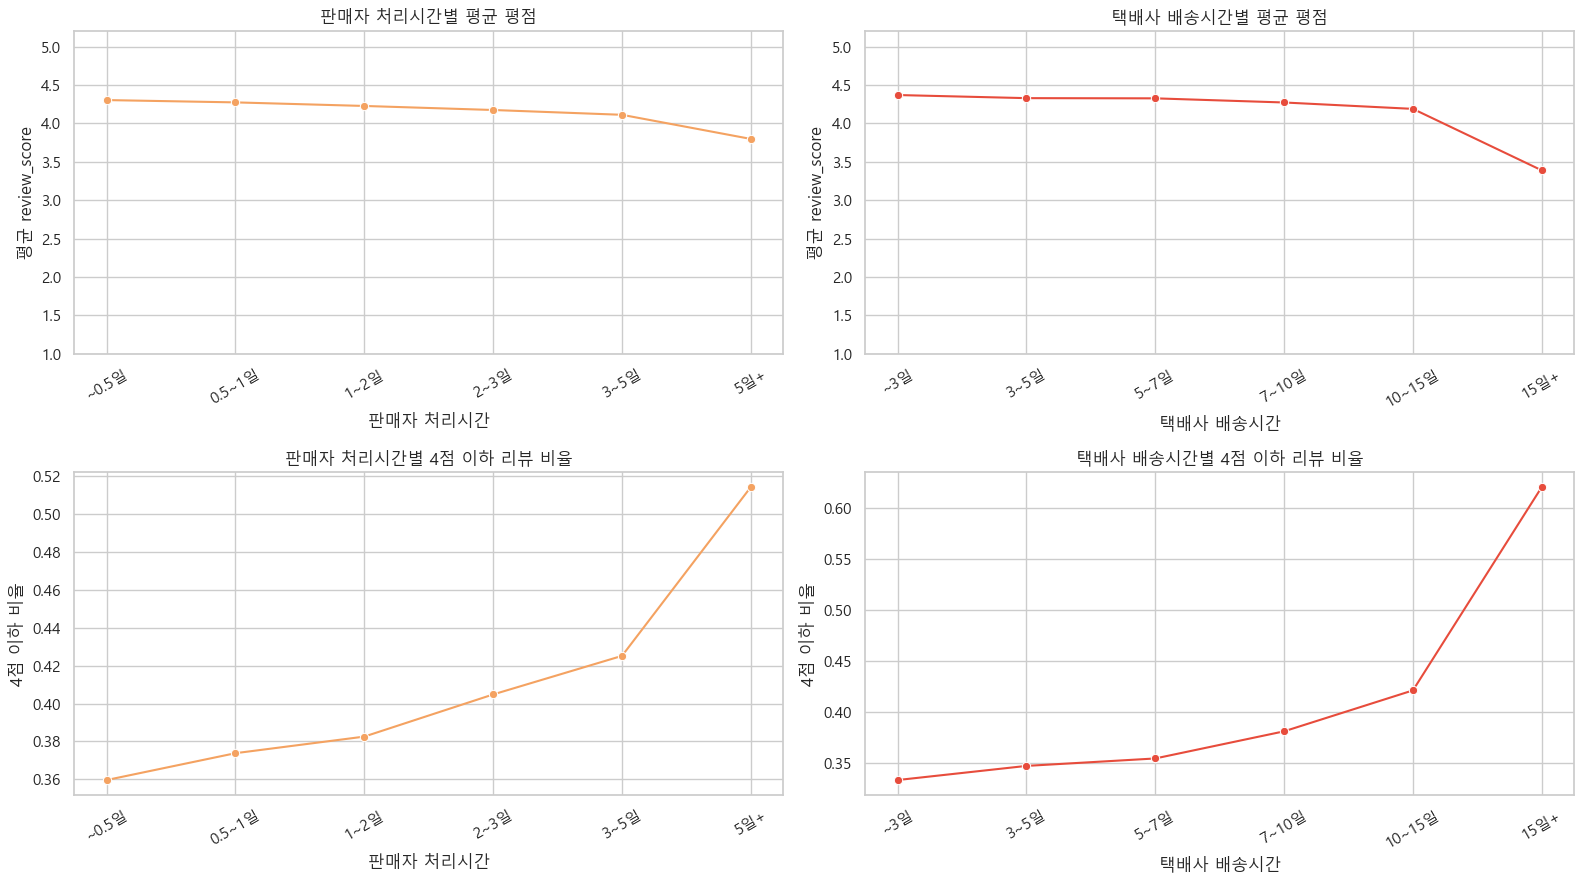

In [ ]:
# 판매자 처리시간과 택배사 배송시간이 평점에 미치는 영향을 비교합니다.
impact_df = reviewed.copy()

if "anomaly_flag" in impact_df.columns:
    impact_df = impact_df.loc[impact_df["anomaly_flag"].fillna(0).eq(0)].copy()

impact_df["seller_process_days"] = pd.to_numeric(impact_df["carrier_lead_hours"], errors="coerce") / 24
impact_df["carrier_delivery_days"] = pd.to_numeric(impact_df["last_mile_days"], errors="coerce")
impact_df["review_score_mean"] = pd.to_numeric(impact_df["review_score_mean"], errors="coerce")
impact_df["low_review"] = impact_df["review_score_mean"].le(4)

impact_df = impact_df.dropna(
    subset=["review_score_mean", "seller_process_days", "carrier_delivery_days"]
).copy()
impact_df = impact_df.loc[
    impact_df["seller_process_days"].ge(0) & impact_df["carrier_delivery_days"].ge(0)
].copy()

impact_df["seller_process_bin"] = pd.cut(
    impact_df["seller_process_days"],
    bins=[-np.inf, 0.5, 1, 2, 3, 5, np.inf],
    labels=["~0.5일", "0.5~1일", "1~2일", "2~3일", "3~5일", "5일+"],
)

impact_df["carrier_delivery_bin"] = pd.cut(
    impact_df["carrier_delivery_days"],
    bins=[-np.inf, 3, 5, 7, 10, 15, np.inf],
    labels=["~3일", "3~5일", "5~7일", "7~10일", "10~15일", "15일+"],
)


def summarize_time_impact(df, bin_col):
    return (
        df.groupby(bin_col, observed=True)
        .agg(
            orders=("order_id", "nunique"),
            avg_review=("review_score_mean", "mean"),
            median_review=("review_score_mean", "median"),
            low_review_rate=("low_review", "mean"),
        )
        .reset_index()
    )


seller_impact = summarize_time_impact(impact_df, "seller_process_bin")
carrier_impact = summarize_time_impact(impact_df, "carrier_delivery_bin")

display(seller_impact)
display(carrier_impact)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))

sns.lineplot(data=seller_impact, x="seller_process_bin", y="avg_review", marker="o", ax=axes[0, 0], color="#F4A261")
axes[0, 0].set_title("판매자 처리시간별 평균 평점")
axes[0, 0].set_xlabel("판매자 처리시간")
axes[0, 0].set_ylabel("평균 review_score")
axes[0, 0].tick_params(axis="x", rotation=30)
axes[0, 0].set_ylim(1, 5.2)

sns.lineplot(data=seller_impact, x="seller_process_bin", y="low_review_rate", marker="o", ax=axes[1, 0], color="#F4A261")
axes[1, 0].set_title("판매자 처리시간별 4점 이하 리뷰 비율")
axes[1, 0].set_xlabel("판매자 처리시간")
axes[1, 0].set_ylabel("4점 이하 비율")
axes[1, 0].tick_params(axis="x", rotation=30)

sns.lineplot(data=carrier_impact, x="carrier_delivery_bin", y="avg_review", marker="o", ax=axes[0, 1], color="#E74C3C")
axes[0, 1].set_title("택배사 배송시간별 평균 평점")
axes[0, 1].set_xlabel("택배사 배송시간")
axes[0, 1].set_ylabel("평균 review_score")
axes[0, 1].tick_params(axis="x", rotation=30)
axes[0, 1].set_ylim(1, 5.2)

sns.lineplot(data=carrier_impact, x="carrier_delivery_bin", y="low_review_rate", marker="o", ax=axes[1, 1], color="#E74C3C")
axes[1, 1].set_title("택배사 배송시간별 4점 이하 리뷰 비율")
axes[1, 1].set_xlabel("택배사 배송시간")
axes[1, 1].set_ylabel("4점 이하 비율")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


,n_orders,r2
0,94449,0.137657


,metric,column,daily_score_change,standardized_score_change,abs_standardized_impact
1,택배사 배송시간,carrier_delivery_days,-0.065324,-0.491960,0.491960
0,판매자 처리시간,seller_process_days,-0.069996,-0.203931,0.203931


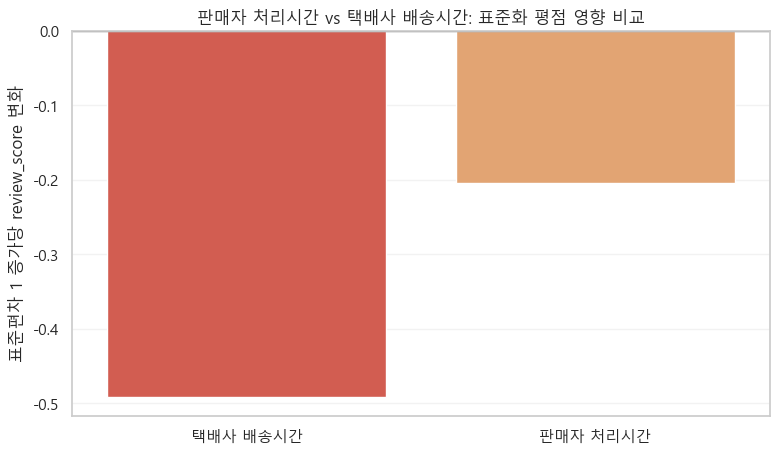

In [ ]:
# 추가 패키지 없이 numpy OLS로 두 시간 변수의 영향력을 같은 모델에서 비교합니다.
# 계수는 인과효과가 아니라, 통제변수를 함께 둔 상태의 조건부 관계로 해석합니다.
model_df = impact_df.copy()

numeric_controls = [
    col for col in ["estimated_delivery_days", "price", "freight_value"]
    if col in model_df.columns
]
model_cols = ["review_score_mean", "seller_process_days", "carrier_delivery_days", *numeric_controls]
model_df = model_df.dropna(subset=model_cols).copy()

numeric_features = ["seller_process_days", "carrier_delivery_days", *numeric_controls]
for col in numeric_features:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")
    upper = model_df[col].quantile(0.99)
    model_df[col] = model_df[col].clip(upper=upper)

state_dummies = pd.DataFrame(index=model_df.index)
if "customer_state" in model_df.columns:
    state_dummies = pd.get_dummies(model_df["customer_state"], prefix="state", drop_first=True, dtype=float)

X_daily = pd.concat([model_df[numeric_features], state_dummies], axis=1)
X_daily.insert(0, "intercept", 1.0)
y = model_df["review_score_mean"].astype(float)

daily_beta = pd.Series(
    np.linalg.lstsq(X_daily.to_numpy(dtype=float), y.to_numpy(dtype=float), rcond=None)[0],
    index=X_daily.columns,
)

standardized_numeric = model_df[numeric_features].copy()
standardized_numeric = (standardized_numeric - standardized_numeric.mean()) / standardized_numeric.std(ddof=0)
X_std = pd.concat([standardized_numeric, state_dummies], axis=1)
X_std.insert(0, "intercept", 1.0)

std_beta = pd.Series(
    np.linalg.lstsq(X_std.to_numpy(dtype=float), y.to_numpy(dtype=float), rcond=None)[0],
    index=X_std.columns,
)

y_hat = X_daily.to_numpy(dtype=float) @ daily_beta.to_numpy(dtype=float)
ss_res = np.square(y.to_numpy(dtype=float) - y_hat).sum()
ss_tot = np.square(y.to_numpy(dtype=float) - y.mean()).sum()
r2 = 1 - ss_res / ss_tot

impact_compare = pd.DataFrame(
    {
        "metric": ["판매자 처리시간", "택배사 배송시간"],
        "column": ["seller_process_days", "carrier_delivery_days"],
        "daily_score_change": [
            daily_beta["seller_process_days"],
            daily_beta["carrier_delivery_days"],
        ],
        "standardized_score_change": [
            std_beta["seller_process_days"],
            std_beta["carrier_delivery_days"],
        ],
    }
)
impact_compare["abs_standardized_impact"] = impact_compare["standardized_score_change"].abs()
impact_compare = impact_compare.sort_values("abs_standardized_impact", ascending=False)

display(pd.DataFrame({"n_orders": [model_df["order_id"].nunique()], "r2": [r2]}))
display(impact_compare)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=impact_compare,
    x="metric",
    y="standardized_score_change",
    hue="metric",
    palette=["#E74C3C", "#F4A261"],
    legend=False,
)
plt.axhline(0, color="gray", linewidth=1)
plt.title("판매자 처리시간 vs 택배사 배송시간: 표준화 평점 영향 비교")
plt.xlabel("")
plt.ylabel("표준편차 1 증가당 review_score 변화")
plt.grid(axis="y", alpha=0.25)
plt.show()


### 분석 결과 해석 방법

- 구간별 EDA에서는 시간이 길어질수록 `avg_review`가 내려가고 `low_review_rate`가 올라가는지 확인합니다. 이 흐름이 더 가파른 쪽이 평점에 더 민감하게 연결된 후보입니다.
- 회귀 비교표의 `daily_score_change`는 해당 시간이 **1일 증가할 때 평균 평점이 얼마나 변하는지**를 뜻합니다. 두 값 모두 음수라면 시간이 길수록 평점에 부정적이라는 의미입니다.
- `standardized_score_change`는 두 변수의 분포 차이를 맞춘 비교입니다. 절댓값이 더 큰 변수가 평점 변동과 더 강하게 연결됩니다.
- 단, 이 분석은 인과관계 확정이 아니라 조건부 관계 비교입니다. 지역, 가격, 배송비, 예상 배송일을 일부 통제했지만 상품 특성, 고객 기대치, 판매자 품질 같은 숨은 요인이 남아 있을 수 있습니다.


## 4. 지연일에 대한 판매자 처리시간 vs 택배사 배송시간 영향 비교

이번에는 평점이 아니라 `late_days` 자체를 결과 변수로 둡니다. 즉, 판매자 처리시간과 택배사 배송시간 중 어떤 쪽이 배송 예정일 대비 지연을 더 크게 만드는지 확인합니다.

주의할 점은 `late_days = 실제 고객 수령일 - 배송 예정일`이고, 판매자 처리시간과 택배사 배송시간은 실제 배송 리드타임의 구성요소라는 점입니다. 따라서 이 분석은 엄밀한 인과효과라기보다, **지연일 증가와 더 강하게 연결된 병목 구간**을 찾는 분석으로 해석하는 것이 안전합니다.


,seller_process_bin,orders,avg_late_days,median_late_days,late_rate,avg_review
0,~0.5일,9829,-13.191920,-13.209479,0.042527,4.304405
1,0.5~1일,17792,-12.421717,-12.527205,0.049910,4.274327
2,1~2일,22686,-11.698004,-12.216528,0.065988,4.227820
3,2~3일,14051,-11.252467,-12.039213,0.069746,4.175148
4,3~5일,16267,-10.680803,-11.155810,0.085756,4.112559
5,5일+,13824,-7.711154,-8.067598,0.177228,3.797996


,carrier_delivery_bin,orders,avg_late_days,median_late_days,late_rate,avg_review
0,~3일,15714,-11.152639,-10.331638,0.024119,4.370105
1,3~5일,13112,-13.803920,-13.264051,0.019753,4.329584
2,5~7일,16500,-14.260895,-14.031175,0.014788,4.326970
3,7~10일,18127,-14.234457,-13.262639,0.019860,4.273018
4,10~15일,16240,-11.752532,-11.155561,0.037315,4.189717
5,15일+,14756,-0.952837,-2.449688,0.391705,3.388610


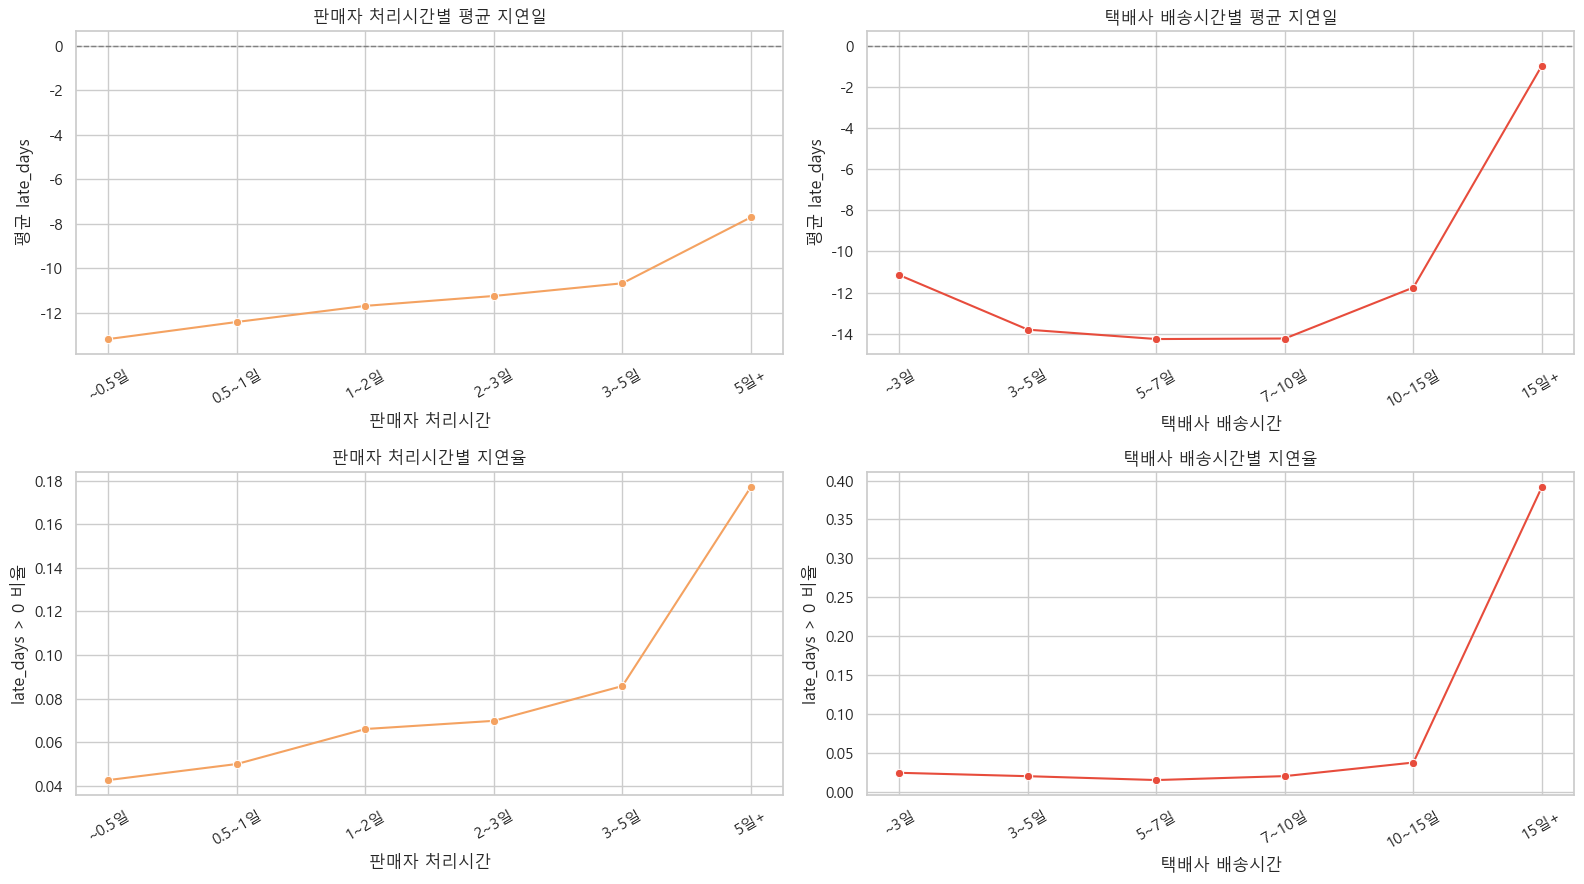

In [ ]:
# 지연일(late_days)에 대한 판매자 처리시간과 택배사 배송시간의 영향을 비교합니다.
late_driver_df = reviewed.copy()

if "anomaly_flag" in late_driver_df.columns:
    late_driver_df = late_driver_df.loc[late_driver_df["anomaly_flag"].fillna(0).eq(0)].copy()

late_driver_df["seller_process_days"] = pd.to_numeric(late_driver_df["carrier_lead_hours"], errors="coerce") / 24
late_driver_df["carrier_delivery_days"] = pd.to_numeric(late_driver_df["last_mile_days"], errors="coerce")
late_driver_df["late_days"] = pd.to_numeric(late_driver_df["late_days"], errors="coerce")
late_driver_df["is_late_actual"] = late_driver_df["late_days"].gt(0)

late_driver_df = late_driver_df.dropna(
    subset=["late_days", "seller_process_days", "carrier_delivery_days"]
).copy()
late_driver_df = late_driver_df.loc[
    late_driver_df["seller_process_days"].ge(0) & late_driver_df["carrier_delivery_days"].ge(0)
].copy()

late_driver_df["seller_process_bin"] = pd.cut(
    late_driver_df["seller_process_days"],
    bins=[-np.inf, 0.5, 1, 2, 3, 5, np.inf],
    labels=["~0.5일", "0.5~1일", "1~2일", "2~3일", "3~5일", "5일+"],
)

late_driver_df["carrier_delivery_bin"] = pd.cut(
    late_driver_df["carrier_delivery_days"],
    bins=[-np.inf, 3, 5, 7, 10, 15, np.inf],
    labels=["~3일", "3~5일", "5~7일", "7~10일", "10~15일", "15일+"],
)


def summarize_late_driver(df, bin_col):
    return (
        df.groupby(bin_col, observed=True)
        .agg(
            orders=("order_id", "nunique"),
            avg_late_days=("late_days", "mean"),
            median_late_days=("late_days", "median"),
            late_rate=("is_late_actual", "mean"),
            avg_review=("review_score_mean", "mean"),
        )
        .reset_index()
    )


seller_late_impact = summarize_late_driver(late_driver_df, "seller_process_bin")
carrier_late_impact = summarize_late_driver(late_driver_df, "carrier_delivery_bin")

display(seller_late_impact)
display(carrier_late_impact)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))

sns.lineplot(data=seller_late_impact, x="seller_process_bin", y="avg_late_days", marker="o", ax=axes[0, 0], color="#F4A261")
axes[0, 0].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[0, 0].set_title("판매자 처리시간별 평균 지연일")
axes[0, 0].set_xlabel("판매자 처리시간")
axes[0, 0].set_ylabel("평균 late_days")
axes[0, 0].tick_params(axis="x", rotation=30)

sns.lineplot(data=seller_late_impact, x="seller_process_bin", y="late_rate", marker="o", ax=axes[1, 0], color="#F4A261")
axes[1, 0].set_title("판매자 처리시간별 지연율")
axes[1, 0].set_xlabel("판매자 처리시간")
axes[1, 0].set_ylabel("late_days > 0 비율")
axes[1, 0].tick_params(axis="x", rotation=30)

sns.lineplot(data=carrier_late_impact, x="carrier_delivery_bin", y="avg_late_days", marker="o", ax=axes[0, 1], color="#E74C3C")
axes[0, 1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[0, 1].set_title("택배사 배송시간별 평균 지연일")
axes[0, 1].set_xlabel("택배사 배송시간")
axes[0, 1].set_ylabel("평균 late_days")
axes[0, 1].tick_params(axis="x", rotation=30)

sns.lineplot(data=carrier_late_impact, x="carrier_delivery_bin", y="late_rate", marker="o", ax=axes[1, 1], color="#E74C3C")
axes[1, 1].set_title("택배사 배송시간별 지연율")
axes[1, 1].set_xlabel("택배사 배송시간")
axes[1, 1].set_ylabel("late_days > 0 비율")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


,n_orders,r2
0,94449,0.888385


,metric,column,daily_late_days_change,standardized_late_days_change,abs_standardized_impact
1,택배사 배송시간,carrier_delivery_days,1.111747,8.372622,8.372622
0,판매자 처리시간,seller_process_days,1.099166,3.202400,3.202400


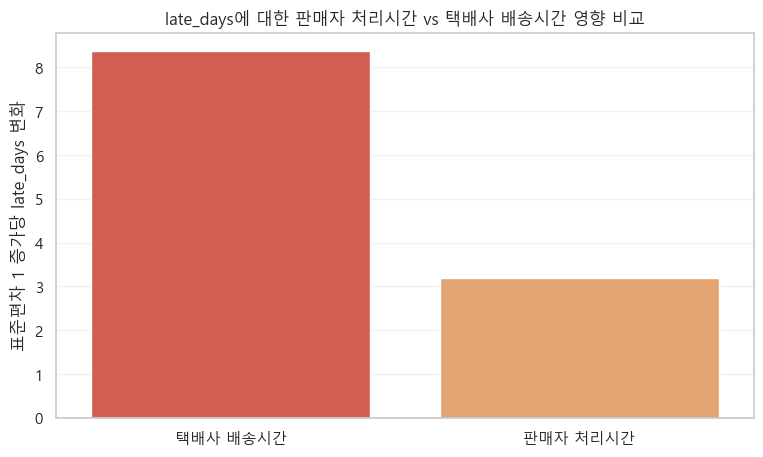

In [ ]:
# 같은 모델 안에서 두 시간이 late_days를 얼마나 밀어 올리는지 비교합니다.
late_model_df = late_driver_df.copy()

numeric_controls = [
    col for col in ["estimated_delivery_days", "price", "freight_value"]
    if col in late_model_df.columns
]
model_cols = ["late_days", "seller_process_days", "carrier_delivery_days", *numeric_controls]
late_model_df = late_model_df.dropna(subset=model_cols).copy()

numeric_features = ["seller_process_days", "carrier_delivery_days", *numeric_controls]
for col in numeric_features:
    late_model_df[col] = pd.to_numeric(late_model_df[col], errors="coerce")
    upper = late_model_df[col].quantile(0.99)
    late_model_df[col] = late_model_df[col].clip(upper=upper)

state_dummies = pd.DataFrame(index=late_model_df.index)
if "customer_state" in late_model_df.columns:
    state_dummies = pd.get_dummies(late_model_df["customer_state"], prefix="state", drop_first=True, dtype=float)

X_daily = pd.concat([late_model_df[numeric_features], state_dummies], axis=1)
X_daily.insert(0, "intercept", 1.0)
y = late_model_df["late_days"].astype(float)

daily_beta = pd.Series(
    np.linalg.lstsq(X_daily.to_numpy(dtype=float), y.to_numpy(dtype=float), rcond=None)[0],
    index=X_daily.columns,
)

standardized_numeric = late_model_df[numeric_features].copy()
standardized_numeric = (standardized_numeric - standardized_numeric.mean()) / standardized_numeric.std(ddof=0)
X_std = pd.concat([standardized_numeric, state_dummies], axis=1)
X_std.insert(0, "intercept", 1.0)

std_beta = pd.Series(
    np.linalg.lstsq(X_std.to_numpy(dtype=float), y.to_numpy(dtype=float), rcond=None)[0],
    index=X_std.columns,
)

y_hat = X_daily.to_numpy(dtype=float) @ daily_beta.to_numpy(dtype=float)
ss_res = np.square(y.to_numpy(dtype=float) - y_hat).sum()
ss_tot = np.square(y.to_numpy(dtype=float) - y.mean()).sum()
r2 = 1 - ss_res / ss_tot

late_driver_compare = pd.DataFrame(
    {
        "metric": ["판매자 처리시간", "택배사 배송시간"],
        "column": ["seller_process_days", "carrier_delivery_days"],
        "daily_late_days_change": [
            daily_beta["seller_process_days"],
            daily_beta["carrier_delivery_days"],
        ],
        "standardized_late_days_change": [
            std_beta["seller_process_days"],
            std_beta["carrier_delivery_days"],
        ],
    }
)
late_driver_compare["abs_standardized_impact"] = late_driver_compare["standardized_late_days_change"].abs()
late_driver_compare = late_driver_compare.sort_values("abs_standardized_impact", ascending=False)

display(pd.DataFrame({"n_orders": [late_model_df["order_id"].nunique()], "r2": [r2]}))
display(late_driver_compare)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=late_driver_compare,
    x="metric",
    y="standardized_late_days_change",
    hue="metric",
    palette=["#E74C3C", "#F4A261"],
    legend=False,
)
plt.axhline(0, color="gray", linewidth=1)
plt.title("late_days에 대한 판매자 처리시간 vs 택배사 배송시간 영향 비교")
plt.xlabel("")
plt.ylabel("표준편차 1 증가당 late_days 변화")
plt.grid(axis="y", alpha=0.25)
plt.show()


### 분석 결과 해석 방법

- `avg_late_days`가 빠르게 올라가는 구간은 배송 예정일을 넘기는 데 더 직접적으로 연결된 병목 후보입니다.
- `late_rate`는 해당 구간의 주문 중 실제 지연(`late_days > 0`)이 발생한 비율입니다. 평균 지연일과 지연율이 함께 올라가면 더 강한 신호로 볼 수 있습니다.
- 회귀표의 `daily_late_days_change`는 해당 시간이 **1일 증가할 때 late_days가 평균적으로 몇 일 증가하는지**를 뜻합니다.
- `standardized_late_days_change`는 두 변수의 스케일 차이를 맞춘 영향력입니다. 절댓값이 더 큰 쪽이 지연일 변동과 더 강하게 연결됩니다.
- 다만 `late_days`는 실제 수령일에서 예정일을 뺀 값이고, 두 시간 변수는 실제 리드타임의 구성요소입니다. 따라서 이 결과는 원인 확정이 아니라, 지연을 키우는 병목 우선순위를 정하는 근거로 사용하는 것이 좋습니다.


## 5. 배송일수별 평균 평점 EDA

배송일수(`delivery_days_clean`) 자체는 지역/거리/예상 배송일 차이가 섞여 있으므로 메인 근거보다는 보조 지표로 봅니다. 여기서는 배송일수 구간별 평균 평점이 어떻게 움직이는지만 확인합니다.



,delivery_days_bin,orders,avg_review,median_review,five_star_rate,low_review_rate
0,~3일,8302,4.461796,5.0,0.709347,0.290532
1,4~5일,10351,4.410299,5.0,0.676167,0.323544
2,6~7일,14090,4.376757,5.0,0.661675,0.337473
3,8~10일,18026,4.324226,5.0,0.637579,0.361922
4,11~14일,17732,4.253102,5.0,0.603260,0.396120
5,15~21일,15156,4.102600,5.0,0.542096,0.456849
6,22일+,10792,3.005174,3.0,0.296516,0.703299


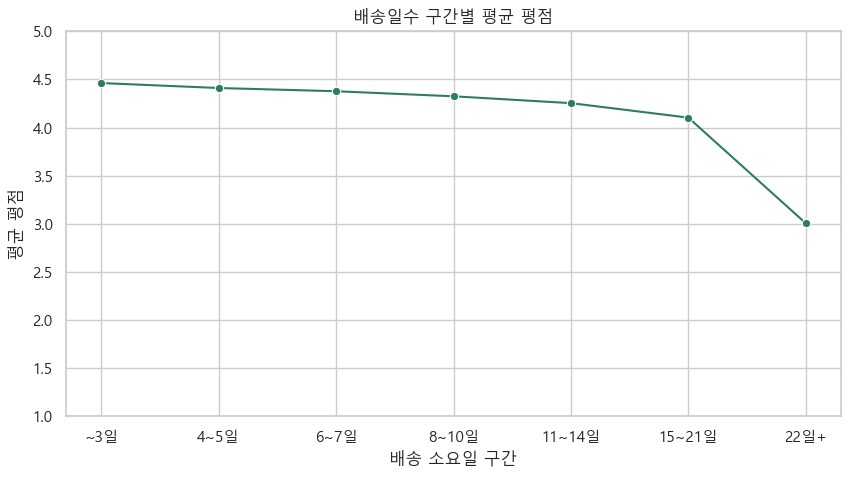

In [ ]:
delivery_bins = [-np.inf, 3, 5, 7, 10, 14, 21, np.inf]
delivery_labels = ["~3일", "4~5일", "6~7일", "8~10일", "11~14일", "15~21일", "22일+"]

reviewed["delivery_days_bin"] = pd.cut(
    reviewed["delivery_days_clean"], bins=delivery_bins, labels=delivery_labels
)

delivery_rating = (
    reviewed.dropna(subset=["delivery_days_bin", "review_score_mean"])
    .groupby("delivery_days_bin", observed=True)
    .agg(
        orders=("order_id", "nunique"),
        avg_review=("review_score_mean", "mean"),
        median_review=("review_score_mean", "median"),
        five_star_rate=("is_5star", "mean"),
        low_review_rate=("is_4_or_less", "mean"),
    )
    .reset_index()
)

display(delivery_rating)

plt.figure(figsize=(10, 5))
sns.lineplot(data=delivery_rating, x="delivery_days_bin", y="avg_review", marker="o", color="#2E7D5B")
plt.title("배송일수 구간별 평균 평점")
plt.xlabel("배송 소요일 구간")
plt.ylabel("평균 평점")
plt.ylim(1, 5)
plt.show()


### 분석 결과 해석

- **~3일 배송**은 평균 평점이 약 **4.46점**으로 가장 높고, 4점 이하 비율은 **29.1%**입니다.
- **4~10일 배송** 구간도 평균 평점이 대체로 **4.32~4.41점** 수준으로 비교적 안정적입니다.
- **11~14일**은 평균 평점이 약 **4.25점**, **15~21일**은 약 **4.10점**으로 완만히 낮아집니다.
- **22일 이상**부터 평균 평점이 약 **3.01점**으로 크게 하락하고, 4점 이하 비율도 **70.3%**까지 상승합니다.

다만 이 결과는 장거리/권역 간 배송이 섞인 값이라, 결론의 핵심 근거는 `late_days` 분석에 두는 것이 더 엄격합니다.


## 6. 지연 포함/제외 배송 평균 일수와 분포

배송 지연이 전체 배송일수 분포를 얼마나 밀어 올리는지 보기 위해 `anomaly_flag == 0`인 배송 완료 전체와, 그중 `is_late == False`인 지연 제외 정상 배송을 비교합니다. 지연 제외 평균은 고객이 예정일 이내에 받은 주문의 기본 배송 리드타임으로 해석할 수 있습니다.



,metric,value
0,orders_with_late_included,95082.000000
1,avg_delivery_days_with_late,12.152858
2,median_delivery_days_with_late,10.000000
3,p75_delivery_days_with_late,15.000000
4,late_rate,0.081950
5,avg_review_with_late,4.154089
6,low_review_rate_with_late,0.405681
7,non_late_orders,87290.000000
8,avg_delivery_days_without_late,10.464120
9,median_delivery_days_without_late,9.000000


,seller_region,customer_region,orders,avg_delivery_days,median_delivery_days,avg_review,low_review_rate
0,남부,북부,188,20.531915,19.5,4.176471,0.430851
1,남동부,북부,1336,19.488772,18.0,4.210407,0.419910
2,남부,북동부,701,17.840228,17.0,4.179395,0.427960
3,남동부,북동부,6404,16.466583,16.0,4.223529,0.416458
4,중서부,북동부,149,16.342282,15.0,4.288591,0.389262
5,북동부,남부,116,15.232759,14.0,4.443478,0.387931
6,중서부,남부,113,14.141593,13.0,4.433628,0.353982
7,북동부,중서부,106,13.716981,13.0,4.330189,0.396226
8,남부,중서부,602,13.704319,13.0,4.321309,0.350498
9,남동부,중서부,4183,13.276835,13.0,4.247600,0.399235


그래프 표시 범위: 0~46일 / 표시 범위 밖 주문 수: 874건


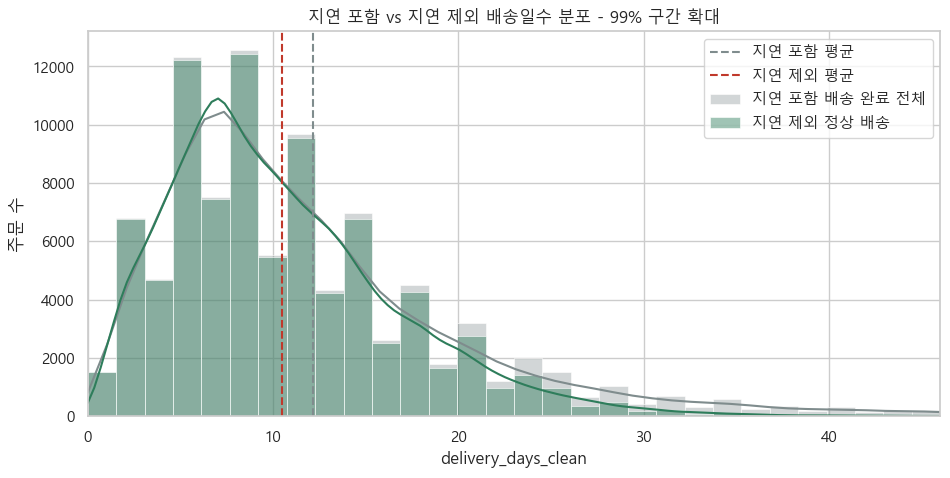

In [ ]:
all_delivered_clean = order_level.loc[
    order_level["is_delivered"].eq(True)
    & order_level["anomaly_flag"].eq(0)
    & order_level["delivery_days_clean"].notna()
].copy()

non_late = all_delivered_clean.loc[
    all_delivered_clean["is_late"].eq(False)
].copy()

late_inclusion_summary = pd.DataFrame({
    "metric": [
        "orders_with_late_included",
        "avg_delivery_days_with_late",
        "median_delivery_days_with_late",
        "p75_delivery_days_with_late",
        "late_rate",
        "avg_review_with_late",
        "low_review_rate_with_late",
        "non_late_orders",
        "avg_delivery_days_without_late",
        "median_delivery_days_without_late",
        "p75_delivery_days_without_late",
        "avg_review_without_late",
        "low_review_rate_without_late",
    ],
    "value": [
        all_delivered_clean["order_id"].nunique(),
        all_delivered_clean["delivery_days_clean"].mean(),
        all_delivered_clean["delivery_days_clean"].median(),
        all_delivered_clean["delivery_days_clean"].quantile(0.75),
        all_delivered_clean["is_late"].mean(),
        all_delivered_clean["review_score_mean"].mean(),
        all_delivered_clean["is_4_or_less"].mean(),
        non_late["order_id"].nunique(),
        non_late["delivery_days_clean"].mean(),
        non_late["delivery_days_clean"].median(),
        non_late["delivery_days_clean"].quantile(0.75),
        non_late["review_score_mean"].mean(),
        non_late["is_4_or_less"].mean(),
    ]
})

display(late_inclusion_summary)

non_late_by_region = (
    non_late.groupby(["seller_region", "customer_region"])
    .agg(
        orders=("order_id", "nunique"),
        avg_delivery_days=("delivery_days_clean", "mean"),
        median_delivery_days=("delivery_days_clean", "median"),
        avg_review=("review_score_mean", "mean"),
        low_review_rate=("is_4_or_less", "mean"),
    )
    .query("orders >= 100")
    .sort_values("avg_delivery_days", ascending=False)
    .reset_index()
)

display(non_late_by_region.head(20))

# 긴 꼬리가 그래프를 눌러 보이지 않게 하므로 기본 차트는 99% 분위수까지만 확대해서 봅니다.
x_max = np.ceil(all_delivered_clean["delivery_days_clean"].quantile(0.99))
outlier_orders = all_delivered_clean.loc[all_delivered_clean["delivery_days_clean"] > x_max, "order_id"].nunique()
print(f"그래프 표시 범위: 0~{x_max:.0f}일 / 표시 범위 밖 주문 수: {outlier_orders:,}건")

plt.figure(figsize=(11, 5))
sns.histplot(
    all_delivered_clean["delivery_days_clean"],
    bins=30,
    binrange=(0, x_max),
    kde=True,
    color="#7F8C8D",
    alpha=0.35,
    label="지연 포함 배송 완료 전체",
)
sns.histplot(
    non_late["delivery_days_clean"],
    bins=30,
    binrange=(0, x_max),
    kde=True,
    color="#2E7D5B",
    alpha=0.45,
    label="지연 제외 정상 배송",
)
plt.axvline(all_delivered_clean["delivery_days_clean"].mean(), color="#7F8C8D", linestyle="--", label="지연 포함 평균")
plt.axvline(non_late["delivery_days_clean"].mean(), color="#C0392B", linestyle="--", label="지연 제외 평균")
plt.xlim(0, x_max)
plt.title("지연 포함 vs 지연 제외 배송일수 분포 - 99% 구간 확대")
plt.xlabel("delivery_days_clean")
plt.ylabel("주문 수")
plt.legend()
plt.show()


### 분석 결과 해석

- 지연 포함 배송 완료 전체의 평균 배송일수는 약 **12.15일**, 중앙값은 **10일**, 75% 분위수는 **15일**입니다.
- 지연을 제외한 정상 배송의 평균 배송일수는 약 **10.46일**, 중앙값은 **9일**, 75% 분위수는 **14일**입니다.
- 배송 완료 정상 데이터 중 지연 주문 비율은 약 **8.2%**입니다.
- 지연을 제외하면 평균 배송일수가 약 **1.7일** 줄어듭니다. 즉 전체 배송일수 분포의 오른쪽 꼬리는 소수의 지연 주문이 강하게 늘리는 구조입니다.
- 그래프는 99% 구간까지만 확대해 보여주므로, 극단적으로 긴 배송 건은 별도 이상/장기 배송 케이스로 분리해서 보는 것이 좋습니다.
